✏️ <span style="background-color:#FEDA8B;">
Remember to add your declaration of external resources and collaborations
</span>

# Basics of classification on the *Iris* dataset

## Preamble

### Importing libraries

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/


From the *scikit-learn* library (https://scikit-learn.org/stable/api/index.html), we need the implementations of classification algorithms, including
- `sklearn.tree` for decision trees,
- `sklearn.naive_bayes` for naive Bayes classifiers,
- `sklearn.neighbors` for k-nearest neighbor classifiers,
- etc.

and various analysis pipeline tools such as
- `sklearn.preprocessing` for preprocessing data, e.g. scaling,
- `sklearn.metrics` for calculating performance measures,
- `sklearn.inspection` to display the decision boundaries of trained classifiers,
- `sklearn.model_selection` to run cross-validation experiments.

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn

from sklearn import tree, naive_bayes, neighbors, linear_model, svm, dummy
from sklearn import preprocessing, metrics, inspection, model_selection

plt.rcParams["figure.figsize"] = (10, 5)

### Repeatability

We initialize a `RandomState` instance with a fixed seed and store it as variable `RS`, to be passed as value for the `random_state` parameter to all *scikit-learn* objects that use randomness.
This makes the analysis in this notebook repeatable. That is, it ensures that every time we restart the kernel and run all cells from top to bottom we obtain the same results, so that we can meaningfully discuss them.

If we run cells repeatedly or in a different order, since the sequence of calls to the random number generator will be different, we might obtain different results.
In order to explore the behavior of the methods, for example during development, we set variable `RS` to `None`, so that the global `RandomState` instance from `numpy` will be used.

For details about controlling randomness when using *scikit-learn*, see https://scikit-learn.org/stable/common_pitfalls.html#controlling-randomness.

✏️ <span style="background-color:#FEDA8B;">
Set the value of `SEED` in the first line below to your student number.
</span>

In [2]:
SEED = 1
RS = numpy.random.RandomState(SEED)
# RS = None

### Data source

The [*Iris* dataset](https://archive.ics.uci.edu/dataset/53/iris) is the main example dataset used in part I of the course.

This dataset contains physical measurements of iris flowers, as the predictive attributes, accompanied by the indication of the species each specimen belongs to, as the class.

In particular, from the [dataset description](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.names) we can find the list of attributes:


| Name | Unit |
| ---- | ---- |
| sepal length | cm |
| sepal width  | cm |
| petal length | cm |
| petal width  | cm |
| **class** | 'Iris-setosa', 'Iris-versicolor' or 'Iris-virginica' |


The classification task typically considered is to predict the species of a flower specimen based on its physical measurements.

### Loading the data

We load the data from the `iris.data` file. This file does not contain names for the columns, so we provide them as the `names` input parameter to the `read_csv` function.

In [3]:
iris_path = "./iris.data"
cnames = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth", "Class"]
iris_dtf = pandas.read_csv(iris_path, sep=",", names=cnames)

The iris species, recorded in column `Class`, is the classification target. We obtain the counts of specimens of each species, i.e. we tally the occurrences of each value in the `Class` column.

In [4]:
iris_targetname = "Class"
iris_dtf.value_counts(iris_targetname)

Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

We see that the dataset contains three different classes, corresponding each to an iris species, and that the classes are perfectly balanced, with exactly fifty samples each.

### Obtaining basic statistics of the data

We show descriptive statistics. The `Class` variable, containing strings, is automatically excluded by default.

Since all four predictive attributes are numerical, for each of them the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

Recall that the *x*th percentile is the threshold such that *x* percent of values fall below it. In particular, the 50th percentile is the threshold such that fifty percent of values fall below it, and hence half of values are above. It is also known as the *median*.

In [5]:
iris_dtf.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Sepals and petals are on average clearly longer than they are wide, with sepals on average larger than petals.

We show an outline of the dataset, displaying the first and last few rows.

In [6]:
iris_dtf

,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### Visualizing the data

Finally, we visualize the dataset with *seaborn*'s `pairplot` function.

It generates a scatter plot of each of the four predictive attributes against each other predictive attribute, where each dot represents an iris specimen, arranged into a grid. The plots along the diagonal of the grid represent the distribution of the values for the corresponding attribute considered separately. The three iris species are depicted with the same three colors as in the course material.

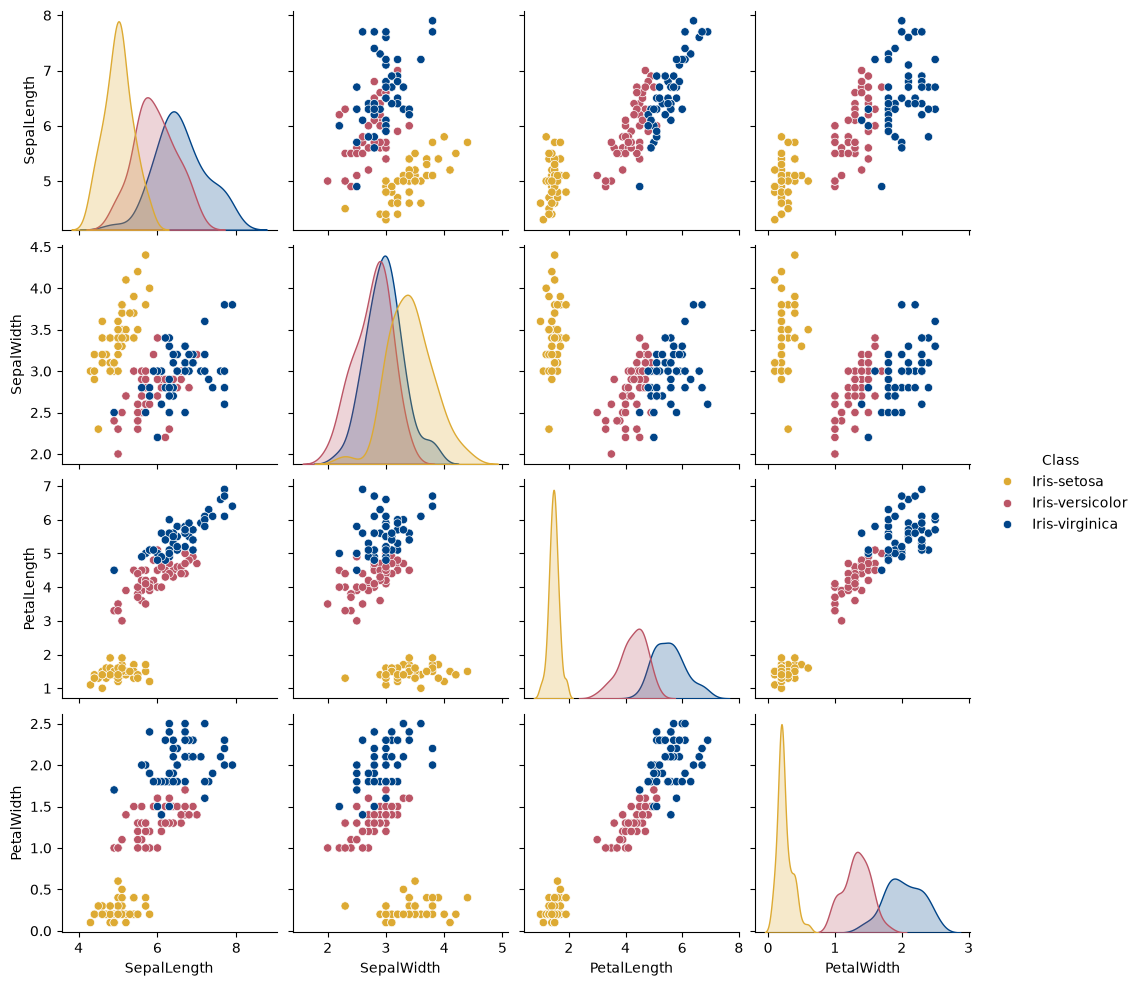

In [7]:
# Create an array with the colors for the different species
species_to_colors = {"Iris-setosa":"#DDAA33", "Iris-versicolor": "#BB5566", "Iris-virginica": "#004488"}
species = sorted(pandas.unique(iris_dtf[iris_targetname]))
iris_palette = seaborn.color_palette([species_to_colors[s] for s in species])

seaborn.pairplot(iris_dtf, hue=iris_targetname, hue_order=species, palette=iris_palette);

In all scatter plots, the clouds of yellow points, representing specimens of *Iris setosa*, are always clearly separated, whereas the clouds of red and blue points, representing respectively specimens of *Iris versicolor* and of *Iris viginica*, show some overlap for all pairs of dimensions and especially in the *sepal length* vs. *sepal width* plot.

The density plots along the diagonal show that *Iris setosa*, in yellow, are typically smaller on all dimensions, except sepal width, where they are on average slightly larger than the other two species. Furthermore, when compared to the other species, the dimensions of the petals of *Iris setosa* specimens do not vary much, with both curves showing a large peak.

Considering the task of classifying iris specimens in this dataset based on their physical measurements, it seems that *Iris setosa* specimens should be relatively easy to identify, while *Iris versicolor* and *Iris viginica* specimens might be more difficult to tell apart, since they have more similar sizes.

## Binary classification of *Iris setosa* and *Iris virginica*

### Preparing the data

We start with the simplest binary classification task, telling apart specimens of *Iris setosa* and *Iris virginica*.
Furthermore, we keep only the sepal dimensions, i.e. attributes `SepalLength` and `SepalWidth`, so that we will be able to easily visualize the data as well as the classifiers' decision boundaries in two dimensions.

We filter the data accordingly and display an outline of the resulting data subset.

In [8]:
irisSV_classes = ["Iris-setosa", "Iris-virginica"]
irisSV_features = ["SepalLength", "SepalWidth"]

irisSV_full = iris_dtf[iris_dtf[iris_targetname].isin(irisSV_classes)]
irisSV_data = irisSV_full[irisSV_features+[iris_targetname]]
irisSV_data

,SepalLength,SepalWidth,Class
0,5.1,3.5,Iris-setosa
1,4.9,3.0,Iris-setosa
2,4.7,3.2,Iris-setosa
3,4.6,3.1,Iris-setosa
4,5.0,3.6,Iris-setosa
...,...,...,...
145,6.7,3.0,Iris-virginica
146,6.3,2.5,Iris-virginica
147,6.5,3.0,Iris-virginica
148,6.2,3.4,Iris-virginica


We restrict the color palette to just the colors needed for the considered species.

In [9]:
irisSV_species_ord = pandas.unique(irisSV_data[iris_targetname])
irisSV_colors_ord = [species_to_colors[s] for s in irisSV_species_ord]
irisSV_cmap = matplotlib.colors.ListedColormap(irisSV_colors_ord)
irisSV_palette = seaborn.color_palette(irisSV_colors_ord)
confusion_cmap = "magma_r"

And we plot the subset of data that we will be using in this first classification task.
We use an equal axis aspect ratio, so that the unit length is the same along both axis, avoiding distance distortions.

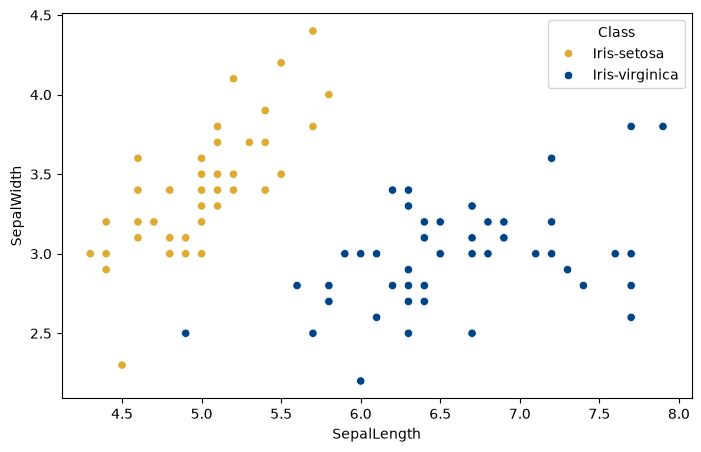

In [10]:
ax = seaborn.scatterplot(x=irisSV_data[irisSV_features[0]], y=irisSV_data[irisSV_features[1]], hue=irisSV_data[iris_targetname],
                hue_order=irisSV_species_ord, palette=irisSV_palette);
ax.set_aspect("equal", adjustable="box")

We divide the data attributes and the target attribute into a test set and a training set, with the former containing twenty percent of the instances while the latter contains the remaining eighty percent of the instances. By default the data is randomly shuffled before splitting.

In [11]:
irisSV_data_train, irisSV_data_test, irisSV_target_train, irisSV_target_test = model_selection.train_test_split(
    irisSV_data[irisSV_features], irisSV_data[iris_targetname], test_size=0.20, random_state=RS)

We copy the original filtered data and add a column `Split` to record whether an instance belongs to the training or test set, which we will use for plotting.

In [12]:
cpSV = irisSV_data.copy()
cpSV["Split"] = ["train"]* len(irisSV_data)
cpSV.loc[irisSV_data_test.index,"Split"] = "test"

### Using a decision tree

We are ready to train a first classifier. We use a decision tree, leaving the parameters to their default values.
We initialize the model and train it by calling the `fit` function on the training data.

In [13]:
irisSV_tree = tree.DecisionTreeClassifier(random_state=RS)
irisSV_tree.fit(irisSV_data_train, irisSV_target_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",RandomState(M...0x7AEAC6321840
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_

We plot the decision boundary of the obtained decision tree, as well as the instances from both training and test sets.

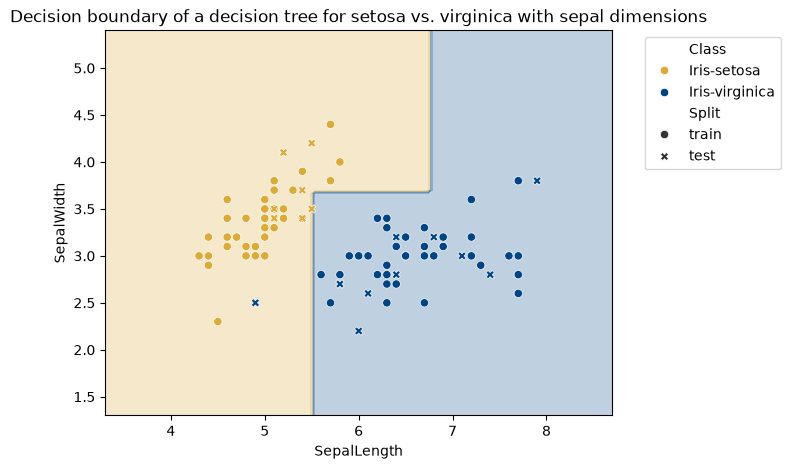

In [14]:
dbd = inspection.DecisionBoundaryDisplay.from_estimator(
    irisSV_tree,
    irisSV_data_train,
    response_method="predict",
    cmap=irisSV_cmap,
    alpha=0.25
)

ax = seaborn.scatterplot(x=cpSV[irisSV_features[0]], y=cpSV[irisSV_features[1]],
                hue=cpSV[iris_targetname], hue_order=irisSV_species_ord, palette=irisSV_palette,
                style=cpSV["Split"], style_order=["train", "test"])

ax.set_aspect("equal", adjustable="box")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Decision boundary of a decision tree for setosa vs. virginica with sepal dimensions");

The background color indicates which class the decision tree predicts for the corresponding point in the feature space. The instances from the training set are depicted with circles whereas those from the test set are depicted with crosses, the color of the markers indicates the ground-truth class of the instances.

For example, a blue cross falling on yellow background represents a test instance that belongs to the species *Iris virginica* according to the ground-truth but which this decision tree predicts as *Iris setosa*.

We display the structure of the decision tree.

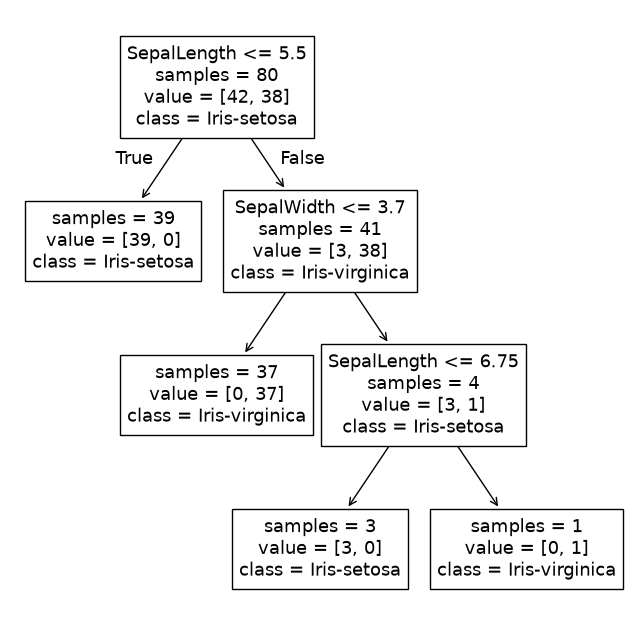

In [15]:
_, ax = plt.subplots(figsize=(8, 8))
tree.plot_tree(irisSV_tree,
    feature_names=irisSV_features,
    class_names=irisSV_tree.classes_.tolist(),
    impurity=False,
    ax=ax);

Each rectangle represents a node in the decision tree. Leaf nodes, containing three lines, represent decisions whereas other nodes, containing four lines, represent tests.
The root node, represented by the rectangle at the top, is the first test in the trained decision tree.
The first line in test nodes indicates the actual test, with the corresponding attribute and threshold value.
The next lines indicate respectively the total number of training samples (*samples*) and the number of training instances of each class (*value*) that were sorted to that node. In the case of the root node, that is all training instances. The last line indicates the majority class among training instances sorted to that node (*class*). In the case of leaf nodes, that is the class predicted for instances sorted to that node.

✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

In particular, in this decision tree, the first test is on the `SepalLength` attribute, such that instances with a value for this attribute less than $5.5$ are sorted to the left branch (True), while instances with a value for this attribute strictly greater than $5.5$ are sorted to the right branch (False).
All thirty-nine instances sorted to the left branch are specimens of *Iris setosa*, so they are not split further, a leaf node is formed to predict class label `Iris-setosa`. Further tests are applied to instances sorted to the right branch from the root node, eventually sorting them into leaf nodes.
In this case, all leaf nodes are pure with respect to the classes of training instances, as visible from the *value* vectors containing exactly one non-zero value each.

We display the *confusion matrix* for the predictions on the test set. Confusion matrices of size two-by-two, as in binary classification, are sometimes called *contingency matrices*.

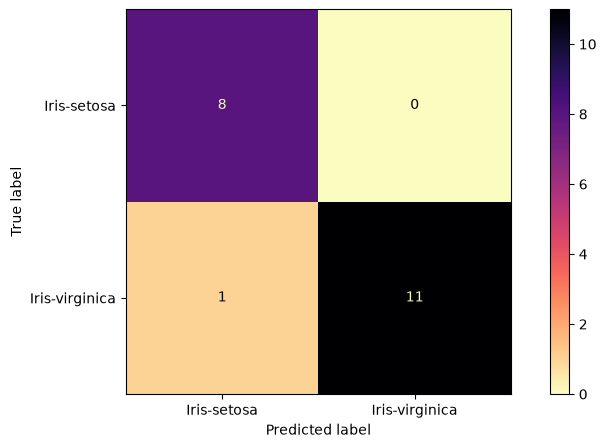

In [16]:
metrics.ConfusionMatrixDisplay.from_estimator(irisSV_tree, irisSV_data_test, irisSV_target_test, cmap=confusion_cmap);

✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

Rows correspond to the ground-truth class labels, whereas columns correspond to predicted labels. In this case, the count in the bottom-left cell corresponds to the number of test instances that are erroneously predicted as *Iris setosa* when in fact they are specimens of *Iris virginica*. In this case, there is exactly one such instance.

We compute the *accuracy*, *precision* and *recall* achieved by the classifier with these predictions.

- **Accuracy** is the fraction of instances that are correctly predicted.
- **Precision** is the fraction of instances, among those that are predicted as positive, which are indeed positive according to the ground-truth.
- **Recall** is the fraction of instances, among those that are positive according to the ground-truth, which are predicted as positive.

The definition of accuracy does not depend on the number and identity of classes. On the other hand, for the definition precision and recall scores to be meaningful, we need to specify a class to be considered as the positive class.

In this case, we make the arbitrary choice to use *Iris setosa* as the positive class, and set parameter `pos_label` accordingly in the calculation of the precision and recall scores.

In [17]:
irisSV_predictions = irisSV_tree.predict(irisSV_data_test)
print(
    "Prediction performance:\n"
    f"\t- Accuracy: {metrics.accuracy_score(irisSV_target_test, irisSV_predictions):.3f}\n"
    f"\t- Precision: {metrics.precision_score(irisSV_target_test, irisSV_predictions, pos_label="Iris-setosa"):.3f}\n"
    f"\t- Recall: {metrics.recall_score(irisSV_target_test, irisSV_predictions, pos_label="Iris-setosa"):.3f}\n"
)

Prediction performance:
	- Accuracy: 0.950
	- Precision: 0.889
	- Recall: 1.000



✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

In this case, as we saw from the confusion matrix, all nine instances of *Iris setosa* (positive class) have been correctly predicted. Of the twelve instances *Iris virginica* (negative class), all but one have been correctly predicted. Accordingly, there are eight true positives (TP), eleven true negatives (TN), one false positive (FN) and zero false negative. The accuracy equals $(8+11)/20 = 0.95$, the precision $8/9=0.889$ and the recall $8/8=1$.

### Using a decision tree of limited depth

Next, we train a second decision tree using the same dataset and the same test-train split.
But this time we limit the depth of the tree to two, by setting the `max_depth` parameter.

In [18]:
irisSV_tree2 = tree.DecisionTreeClassifier(max_depth=2, random_state=RS)
irisSV_tree2.fit(irisSV_data_train, irisSV_target_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",RandomState(M...0x7AEAC6321840
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t``

We plot the decision boundary of this second decision tree, as well as the instances from both training and test sets.

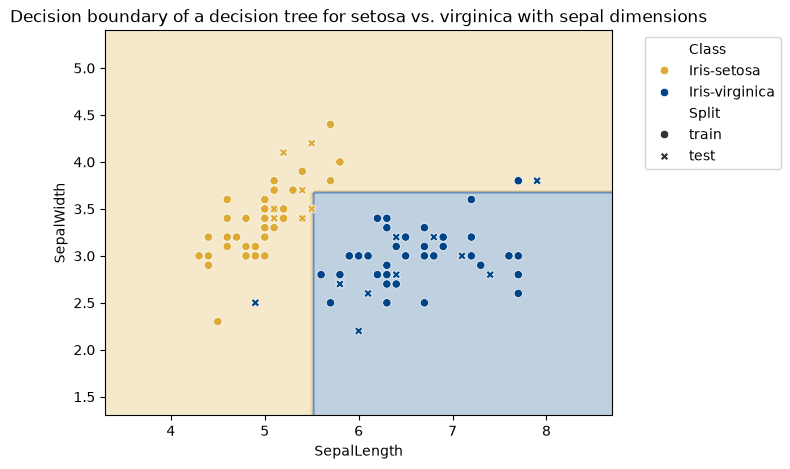

In [19]:
dbd = inspection.DecisionBoundaryDisplay.from_estimator(
    irisSV_tree2,
    irisSV_data_train,
    response_method="predict",
    cmap=irisSV_cmap,
    alpha=0.25,
)

ax = seaborn.scatterplot(x=cpSV[irisSV_features[0]], y=cpSV[irisSV_features[1]],
                hue=cpSV[iris_targetname], hue_order=irisSV_species_ord, palette=irisSV_palette,
                style=cpSV["Split"], style_order=["train", "test"])

ax.set_aspect("equal", adjustable="box")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Decision boundary of a decision tree for setosa vs. virginica with sepal dimensions");

✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

The training and test instances are the same, but we can notice a difference in the decision boundary of the decision tree. The top right corner of the depicted feature space now corresponds to *Iris setosa* predictions, i.e. it now has a yellow background instead of blue.
A blue circle and a blue cross in that area now fall on a yellow background, meaning that this decision tree returns incorrect predictions for them, unlike the previsou decision tree.

We display the structure of the decision tree.

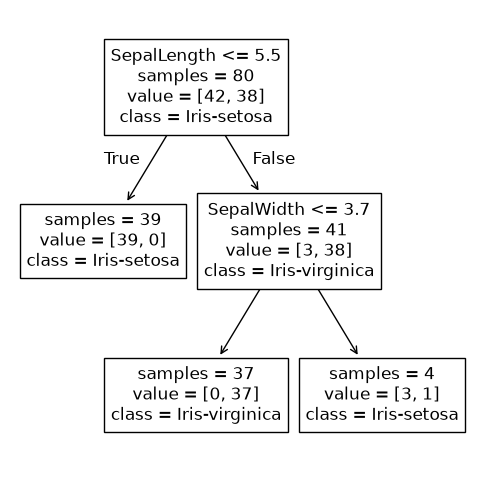

In [20]:
_, ax = plt.subplots(figsize=(6, 6))
tree.plot_tree(irisSV_tree2,
    feature_names=irisSV_features,
    class_names=irisSV_tree2.classes_.tolist(),
    impurity=False,
    ax=ax);

✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

Comparing to the structure of the first tree, we see that the top layers are identical, but the test `SepalLength <= 6.7` has been removed, as it exceeded the allowed depth, and replaced by an impure node, containing three specimens of *Iris setosa* and one of *Iris viriginica* as training instances.
This indeed corresponds to simplifying the decision boundary by removing the predictions of *Iris viriginica* for instances with large sepal lengths, leading to one *Iris virginica* training instance, represented by a blue circle at coordinates (7.7, 3.8), being now predicted as *Iris setosa*.

We display the *confusion matrix* for the predictions on the test set.

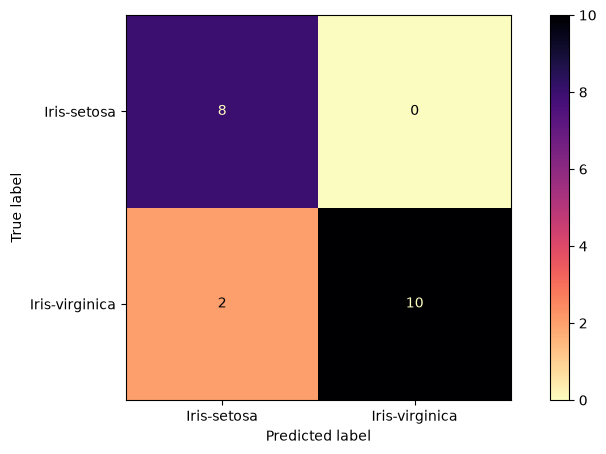

In [21]:
metrics.ConfusionMatrixDisplay.from_estimator(irisSV_tree2, irisSV_data_test, irisSV_target_test, cmap=confusion_cmap);

✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

Compared with the prevision decision tree, the single difference in the predictions on the test sets are one additional instance of *Iris virginica* incorrectly predicted as *Iris setosa*. This corresponds to the blue cross on yellow background at coordinates (7.9, 3.8). As a result, considering *Iris setosa* as the positive class, the count of true negatives decreased by one while the count of false positives increased by one.

We compute the corresponding *accuracy*, *precision* and *recall* achieved by this simpler decision tree classifier.

In [22]:
irisSV_predictions = irisSV_tree2.predict(irisSV_data_test)
print(
    "Prediction performance:\n"
    f"\t- Accuracy: {metrics.accuracy_score(irisSV_target_test, irisSV_predictions):.3f}\n"
    f"\t- Precision: {metrics.precision_score(irisSV_target_test, irisSV_predictions, pos_label="Iris-setosa"):.3f}\n"
    f"\t- Recall: {metrics.recall_score(irisSV_target_test, irisSV_predictions, pos_label="Iris-setosa"):.3f}\n"
)

Prediction performance:
	- Accuracy: 0.900
	- Precision: 0.800
	- Recall: 1.000



✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraph as necessary to ensure it matches with the output after changing the random seed.
</span>

The recall is still perfect, since all test instances of *Iris setosa* are correctly predicted, but the accuracy and precision are lower, since one additional test instance of *Iris viriginica* is incorrectly predicted.

With this dataset, split, and values of the other model parameters, limiting the depth of the tree led to a simpler classifier, at the cost of a somewhat lower precision.

### Using a naive Bayes classifier

Still for the same binary classification task, using the same dataset and the same test-train split, we now train a naive Bayes classifier.

In [23]:
irisSV_gnb = naive_bayes.GaussianNB()
irisSV_gnb.fit(irisSV_data_train, irisSV_target_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[42.,38.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.53,0.47]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U14](2,)","['Iris-setosa','Iris-virginica']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,9.287e-10
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['SepalLength','SepalWidth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[4.95,3.36], [6.64,3.01]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[0.12,0.14], [0.32,0.08]]"


We display the parameters of the trained model, that is, the prior probabilities of both classes, as well as the parameters of the Gaussian distributions independently modeling the two attributes, for each class.

In [24]:
for ci, cname in enumerate(irisSV_gnb.classes_):
    print(f"Gaussian model for class {cname}, class prior={irisSV_gnb.class_prior_[ci]}")
    for ai, att in enumerate(irisSV_gnb.feature_names_in_):
        print(f"\t- {att}: mean={irisSV_gnb.theta_[ci, ai]:.3f}, variance={irisSV_gnb.var_[ci, ai]:.3f}")

Gaussian model for class Iris-setosa, class prior=0.525
	- SepalLength: mean=4.952, variance=0.122
	- SepalWidth: mean=3.364, variance=0.135
Gaussian model for class Iris-virginica, class prior=0.475
	- SepalLength: mean=6.642, variance=0.322
	- SepalWidth: mean=3.011, variance=0.080


✏️ <span style="background-color:#FEDA8B;">
Edit the following paragraphs as necessary to ensure they are coherent and relevant with the analysis after changing the random seed.
</span>

Since there are forty-two instances of *Iris setosa* and thirty-eight instances of *Iris virginica* in the training set, the later receives a slightly lower prior probability, equal to $48/(32+48) = 0.475$.
The values of attribute `SepalLength` for *Iris setosa* are modeled with a Gaussian distribution with mean $4.952$ and variance $0.122$, a distribution typically denoted $\cal{N}(4.952, 0.122)$. Similarly, for the other attribute and the other class.

We plot the decision boundary of the naive Bayes classifier, which consists of the points where the class posterior probabilities are equal.
Here, we set the minimum and maximum values of the two attributes manually, to visualize the decision boundary beyond values appearing in the dataset. In particular, we look what happens for values of `SepalLength` below 4.0.

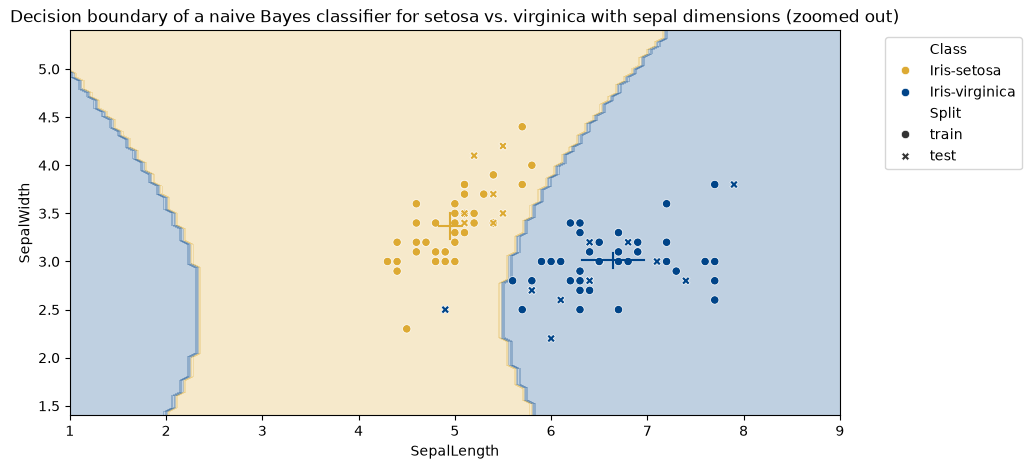

In [25]:
xmin, xmax, ymin, ymax = (1, 9, 1.4, 5.4)
features = numpy.meshgrid(numpy.linspace(xmin, xmax), numpy.linspace(ymin, ymax))
grid_df = pandas.DataFrame(data={irisSV_data_train.columns[0]: features[0].ravel(),
                        irisSV_data_train.columns[1]: features[1].ravel()})

dbd = inspection.DecisionBoundaryDisplay.from_estimator(
    irisSV_gnb,
    grid_df,
    response_method="predict",
    cmap=irisSV_cmap,
    alpha=0.25,
    eps=0
)

ax = seaborn.scatterplot(x=cpSV[irisSV_features[0]], y=cpSV[irisSV_features[1]],
                hue=cpSV[iris_targetname], hue_order=irisSV_species_ord, palette=irisSV_palette,
                style=cpSV["Split"], style_order=["train", "test"])

vfact = 1
for ci, cname in enumerate(irisSV_gnb.classes_):
    ccolor = irisSV_colors_ord[ci]
    plt.plot([irisSV_gnb.theta_[ci, 0], irisSV_gnb.theta_[ci, 0]],
         [irisSV_gnb.theta_[ci, 1]-vfact*irisSV_gnb.var_[ci, 1], irisSV_gnb.theta_[ci, 1]+vfact*irisSV_gnb.var_[ci, 1]], "-", color=ccolor)
    plt.plot([irisSV_gnb.theta_[ci, 0]-vfact*irisSV_gnb.var_[ci, 0], irisSV_gnb.theta_[ci, 0]+vfact*irisSV_gnb.var_[ci, 0]],
         [irisSV_gnb.theta_[ci, 1], irisSV_gnb.theta_[ci, 1]], "-", color=ccolor)

ax.set_aspect("equal", adjustable="box")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Decision boundary of a naive Bayes classifier for setosa vs. virginica with sepal dimensions (zoomed out)");

 We see that the prediction turns back to *Iris virginica* for values of `SepalLength` sufficiently small.

We display the *confusion matrix* for the predictions on the test set...

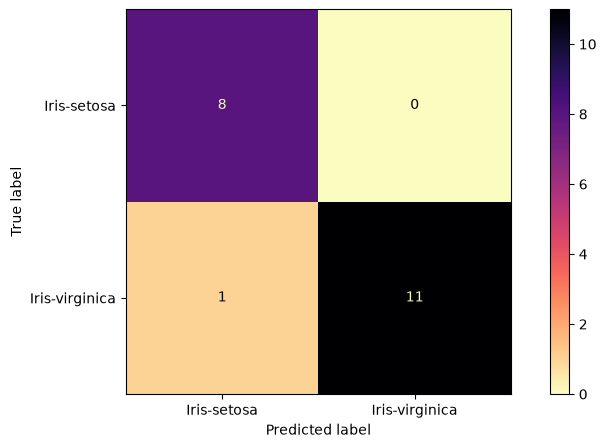

In [26]:
metrics.ConfusionMatrixDisplay.from_estimator(irisSV_gnb, irisSV_data_test, irisSV_target_test, cmap=confusion_cmap);

... and compute the corresponding *accuracy*, *precision* and *recall* scores.

In [27]:
irisSV_predictions = irisSV_gnb.predict(irisSV_data_test)
print(
    "Prediction performance:\n"
    f"\t- Accuracy: {metrics.accuracy_score(irisSV_target_test, irisSV_predictions):.3f}\n"
    f"\t- Precision: {metrics.precision_score(irisSV_target_test, irisSV_predictions, pos_label="Iris-setosa"):.3f}\n"
    f"\t- Recall: {metrics.recall_score(irisSV_target_test, irisSV_predictions, pos_label="Iris-setosa"):.3f}\n"
)

Prediction performance:
	- Accuracy: 0.950
	- Precision: 0.889
	- Recall: 1.000



✏️ <span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the confusion matrix and scores, and to explain what it means in terms of the performance of the classifier.
</span>

## Ternary classification

We turn to the task of classifing instances into the three different classes, i.e. considering all three iris species together.

### Preparing the data

We keep all instances, i.e. all rows in the dataset, but for the first experiment we keep only two attributes to be able to visualize the data and results easily. In particular, we keep the length dimensions, namely attributes `PetalLength` and `SepalLength`.

We filter the data accordingly and display an outline of the resulting data subset.

In [28]:
irisT_features = ["PetalLength", "SepalLength"]
irisT_features = ["PetalLength", "SepalWidth"]

irisT_data = iris_dtf[irisT_features+[iris_targetname]]
irisT_data

,PetalLength,SepalWidth,Class
0,1.4,3.5,Iris-setosa
1,1.4,3.0,Iris-setosa
2,1.3,3.2,Iris-setosa
3,1.5,3.1,Iris-setosa
4,1.4,3.6,Iris-setosa
...,...,...,...
145,5.2,3.0,Iris-virginica
146,5.0,2.5,Iris-virginica
147,5.2,3.0,Iris-virginica
148,5.4,3.4,Iris-virginica


The dataset contains 150 rows, 50 instances of each of the three iris species, and three columns, the two length dimensions plus the target attribute.

We prepare the color map and color palette as needed to plot the three species.

In [29]:
irisT_species_ord = pandas.unique(irisT_data[iris_targetname])
irisT_colors_ord = [species_to_colors[s] for s in irisT_species_ord]
irisT_cmap = matplotlib.colors.ListedColormap(irisT_colors_ord)
irisT_palette = seaborn.color_palette(irisT_colors_ord)

And we plot the subset of data that we will be using in this classification task, i.e. *petal length* vs. *sepal length* for *Iris setosa*, *Iris virginica* but also *Iris versicolor*.

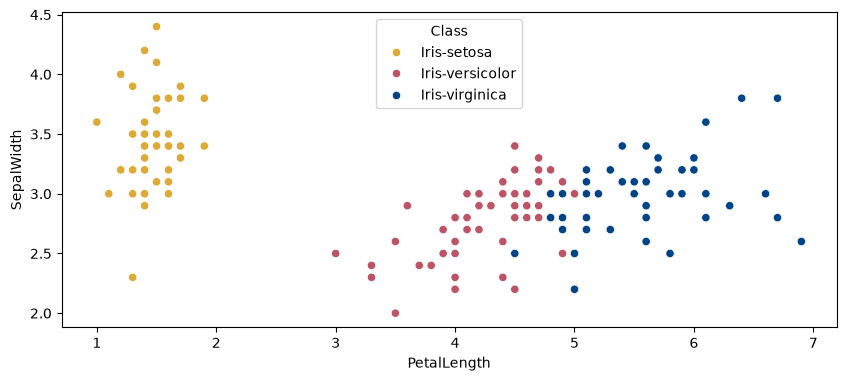

In [30]:
ax = seaborn.scatterplot(x=irisT_data[irisT_features[0]], y=irisT_data[irisT_features[1]], hue=irisT_data[iris_targetname],
                hue_order=irisT_species_ord, palette=irisT_palette);
ax.set_aspect("equal", adjustable="box")

As noticed earlier, while *Iris setosa* instances are clearly separated, there is some overlap between instances from the other two species.

We divide the data attributes and the target attribute into a test set and a training set. By default the data is randomly shuffled before splitting, and the split is done in proportion 1/4--3/4, that is, such that the test set and training set respectively contain one quarter and three quarter of the data instances.

In [31]:
irisT_data_train, irisT_data_test, irisT_target_train, irisT_target_test = model_selection.train_test_split(
    irisT_data[irisT_features], irisT_data[iris_targetname], random_state=RS)

We copy the original filtered data and add a column `Split` to record whether an instance belongs to the training or test set, which we will use for plotting.

In [32]:
cpT = irisT_data.copy()
cpT["Split"] = ["train"]* len(irisT_data)
cpT.loc[irisT_data_test.index,"Split"] = "test"

### Using a decision tree

We are ready to train a classifier. We use a decision tree, leaving the parameters to their default values, except for the maximum depth, which we set to four.

In [33]:
irisT_tree = tree.DecisionTreeClassifier(max_depth=4, random_state=RS)
irisT_tree.fit(irisT_data_train, irisT_target_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",RandomState(M...0x7AEAC6321840
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t``

We plot the decision boundary of the obtained decision tree, as well as the instances from both training and test sets.

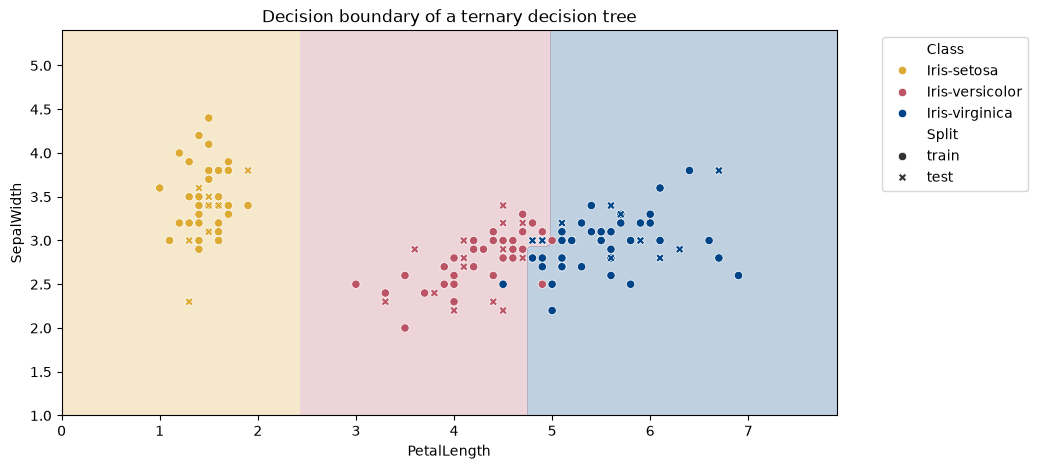

In [34]:
dbd = inspection.DecisionBoundaryDisplay.from_estimator(
    irisT_tree,
    irisT_data_train,
    response_method="predict",
    multiclass_colors=irisT_colors_ord,
    alpha=0.25,
)

seaborn.scatterplot(x=cpT[irisT_features[0]], y=cpT[irisT_features[1]],
                hue=cpT[iris_targetname], hue_order=irisT_species_ord, palette=irisT_palette,
                style=cpT["Split"], style_order=["train", "test"])

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Decision boundary of a ternary decision tree");

✏️ <span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the decision boundary depicted above and discuss what it means.
</span>

We display the structure of the decision tree.

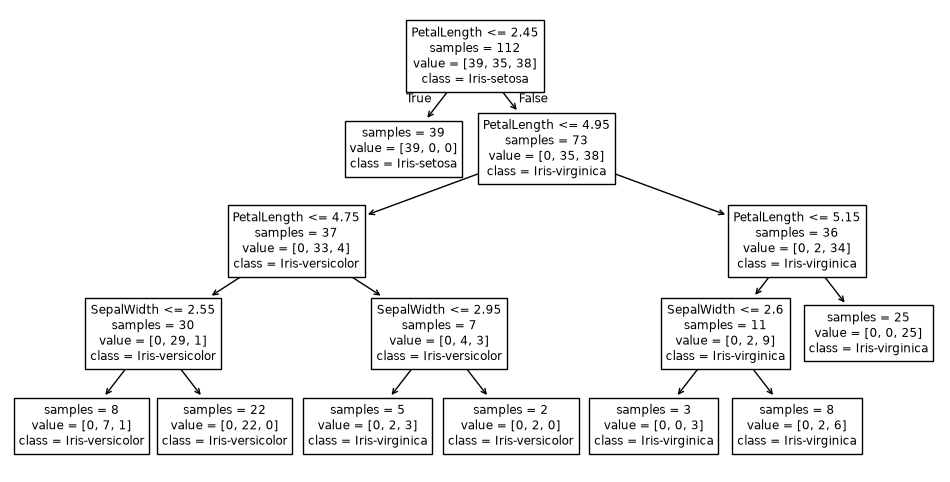

In [35]:
_, ax = plt.subplots(figsize=(12, 6))
_ = tree.plot_tree(
    irisT_tree,
    feature_names=irisT_features,
    class_names=irisT_tree.classes_.tolist(),
    impurity=False,
    ax=ax,
)

✏️ <span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the structure of the decision tree depicted above and discuss what it means.
</span>

We display the *confusion matrix* for the predictions on the test set.

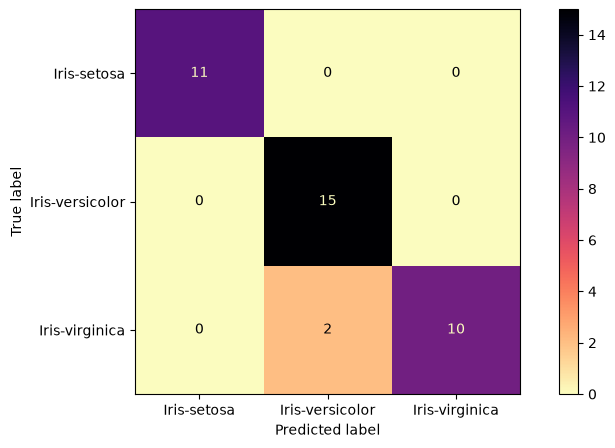

In [36]:
metrics.ConfusionMatrixDisplay.from_estimator(irisT_tree, irisT_data_test, irisT_target_test, cmap=confusion_cmap);

We compute the *accuracy*, *precision* and *recall* achieved by the classifier with these predictions.

As we noted previously, the definition of accuracy does not depend on the number and identity of classes, but the definitions of precision and of recall do.
In the case of multi-class classification, one option is to compute the score considering each class as the positive class, in turn, and aggregate the values. The aggregation can be done by taking the unweighted average (value `macro` for the `average` parameter), or the average weighted by the size of each class (value `weighted` for the `average` parameter). Here we use the former.

In [37]:
irisT_predictions = irisT_tree.predict(irisT_data_test)
print(
    "Prediction performance:\n"
    f"\t- Accuracy: {metrics.accuracy_score(irisT_target_test, irisT_predictions):.3f}\n"
    f"\t- Precision: {metrics.precision_score(irisT_target_test, irisT_predictions, average="macro"):.3f}\n"
    f"\t- Recall: {metrics.recall_score(irisT_target_test, irisT_predictions, average="macro"):.3f}\n"
)

Prediction performance:
	- Accuracy: 0.947
	- Precision: 0.961
	- Recall: 0.944



We can also directly obtain a detailed report of classification performance. It includes per-class *precision*, *recall*, *F1 score* and *support* (the number of test instances belonging to the given class according to the ground-truth), the accuracy, as well as both macro-average and weighted-average *precision*, *recall* and *F1-score*

In [38]:
print(metrics.classification_report(irisT_target_test, irisT_predictions, target_names=irisT_tree.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.83      0.91        12

       accuracy                           0.95        38
      macro avg       0.96      0.94      0.95        38
   weighted avg       0.95      0.95      0.95        38



✏️ <span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the confusion matrix and the different scores reported above, and to explain what it means in terms of the performance of the classifier.
</span>

### Using a linear support vector machine (SVM)

Next, we train a linear support vector machine (SVM) on the same data.

Recall that a support vector machine works by finding a hyperplane to separate the classes. Clearly, since a single hyperplane divides the data space into two, it can only separate the data points into two groups, i.e. it can basically only handle binary classification.
To apply it to classification tasks involving more than two classes, multi-class problems, different strategies might be used. Here we use the *one-versus-rest* strategy (`multi_class` parameter value 'ovr'). Effectively, this means that three separate linear SVMs are trained, each aiming to separate one of the classes from the rest. Then, the predictions of these three binary classifiers are combined into a prediction for the original multi-class task.

In [39]:
irisT_svm = svm.LinearSVC(multi_class="ovr", random_state=RS)
irisT_svm.fit(irisT_data_train, irisT_target_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",RandomState(M...0x7AEAC6321840
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the valu

We plot the decision boundary of the obtained decision tree, as well as the instances from both training and test sets. In addition, we plot the separating hyperplanes (straight lines in this two-dimensional case) for each of the three binary tasks. For example, we depict as a yellow line the hyperplane separating the yellow class (*Iris setosa*) from the other two classes (*Iris versicolor* and *Iris virginica* combined).

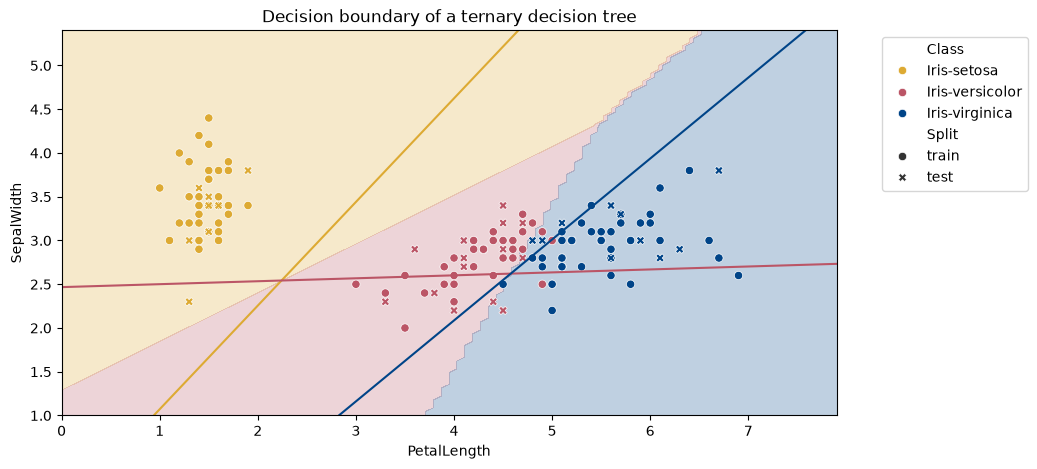

In [40]:
dbd = inspection.DecisionBoundaryDisplay.from_estimator(
    irisT_svm,
    irisT_data_train,
    response_method="predict",
    multiclass_colors=irisT_colors_ord,
    alpha=0.25,
)

ax = seaborn.scatterplot(x=cpT[irisT_features[0]], y=cpT[irisT_features[1]],
                hue=cpT[iris_targetname], hue_order=irisT_species_ord, palette=irisT_palette,
                style=cpT["Split"], style_order=["train", "test"])

x_lims = numpy.array(ax.get_xlim())
y_lims = numpy.array(ax.get_ylim())

for i in range(irisT_svm.coef_.shape[0]):
    plt.plot(x_lims,
             -(x_lims*irisT_svm.coef_[i,0]+irisT_svm.intercept_[i])/irisT_svm.coef_[i,1],
             irisT_colors_ord[i])

ax.set_ylim(y_lims)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Decision boundary of a ternary decision tree");

We see that in these two dimensions, the yellow line clearly separate *Iris setosa* specimens from the rest. Some blue dots fall very close to the blue line, with at least one training instance falling on the wrong side, as well as several test instances (blue crosses above right from the blue line). Separating *Iris virginica* from the rest, especially from *Iris versicolor* is not as straightforward and is not achieved perfectly with a linear boundary. Because *Iris versicolor* specimens lying essentially in between the other two species in this two dimensional space, separating them from the other two species with a straight line is impractical. Indeed, most red train and test instances lie above the red line, on the wrong side.

The decision boundaries for the ternary classification problem, obtained by combining these three binary classifiers' predictions, seems very reasonable, despite few misclassifications between *Iris versicolor* and *Iris virginica*, as expected.

We display the *confusion matrix* for the predictions on the test set...

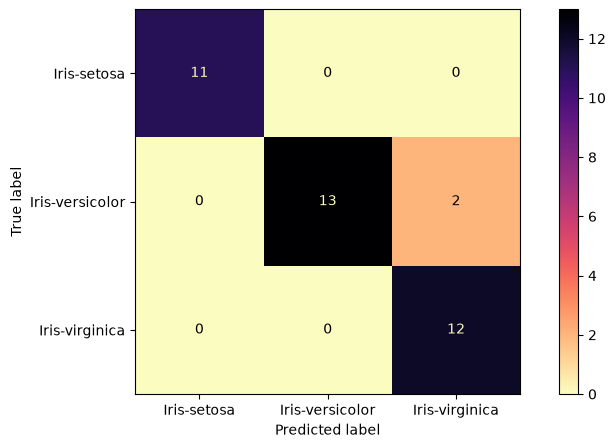

In [41]:
metrics.ConfusionMatrixDisplay.from_estimator(irisT_svm, irisT_data_test, irisT_target_test, cmap=confusion_cmap);

... compute the *accuracy*, *precision* and *recall* achieved by the classifier with these predictions...

In [42]:
irisT_predictions = irisT_svm.predict(irisT_data_test)
print(
    "Prediction performance:\n"
    f"\t- Accuracy: {metrics.accuracy_score(irisT_target_test, irisT_predictions):.3f}\n"
    f"\t- Precision: {metrics.precision_score(irisT_target_test, irisT_predictions, average="macro"):.3f}\n"
    f"\t- Recall: {metrics.recall_score(irisT_target_test, irisT_predictions, average="macro"):.3f}\n"
)

Prediction performance:
	- Accuracy: 0.947
	- Precision: 0.952
	- Recall: 0.956



... and display the report of classification performance.

In [43]:
print(metrics.classification_report(irisT_target_test, irisT_predictions, target_names=irisT_svm.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.87      0.93        15
 Iris-virginica       0.86      1.00      0.92        12

       accuracy                           0.95        38
      macro avg       0.95      0.96      0.95        38
   weighted avg       0.95      0.95      0.95        38



✏️ <span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the confusion matrix and the different scores reported above, and to explain what it means in terms of the performance of the classifier, also in comparison with the decision tree.
</span>

## Comparing classifiers with cross-validation

Finally, we perform a more extensive comparison of classifiers on the ternary task, using cross-validation.

First, we specify the different classifiers we want to use in the comparison.

In [44]:
classifiers = [
    ("Decision Tree", tree.DecisionTreeClassifier(max_depth=3, random_state=RS)),
    ("Naive Bayes", naive_bayes.GaussianNB()),
    ("Linear SVM", svm.LinearSVC(multi_class="ovr", random_state=RS)),
    ("k-NN", neighbors.KNeighborsClassifier(n_neighbors=5)),
    ("Random Baseline", dummy.DummyClassifier(strategy="uniform", random_state=RS))
]

In our comparison, we will use a decision tree with a maximum depth of three, a naive Bayes classifier, a linear SVM and a k-nearest neighbor classifier using the five nearest neighbors (k=5).
The last model is a dummy classifier which to each test instance assigns one of the classes uniformly at random, this serves as a random baseline.

All algorithms can handle multi-class problems out of the box, except for the linear SVM where we apply a one-versus-rest strategy to combine binary predictions.

Next, we define a scoring function which, given a trained classifier as well as features and ground-truth labels for a collection of test instances, computes desired performance scores.
With our custom scoring function, we store the counts from confusion matrix, per-class precision and recall, accuracy, as well as macro-average precision and recall.

In [45]:
def multi_confusion_matrix_scorer(clf, X, y):
    y_pred = clf.predict(X)
    cm = metrics.confusion_matrix(y, y_pred, labels=clf.classes_)
    results = dict([(f"cm-{i}-{j}", cm[i,j]) for i in range(cm.shape[0]) for j in range(cm.shape[1])])
    for i in range(cm.shape[0]):
        results[f"recall_{clf.classes_[i]}"] = cm[i,i]/cm[i,:].sum() if cm[i,:].sum() > 0 else 1.0
        results[f"precision_{clf.classes_[i]}"] = cm[i,i]/cm[:,i].sum() if cm[:,i].sum() > 0 else 1.0
    results["accuracy"] = metrics.accuracy_score(y, y_pred)
    results["precision_macro-avg"] = metrics.precision_score(y, y_pred, average="macro", zero_division=1.0)
    results["recall_macro-avg"] = metrics.recall_score(y, y_pred, average="macro", zero_division=1.0)
    return results

scoring = multi_confusion_matrix_scorer

We setup the cross-validation procedure. Available options include a single round of k-fold cross-validation (`KFold`) or repeated rounds of k-fold cross-validation (`RepeatedKFold`), without or with stratification (`StratifiedKFold` or `RepeatedStratifiedKFold`).

Stratification generates folds that preserves the proportion of instances for each class as in the entire data.
Because the three classes are equally represented in the dataset, the probability that a class is not represented at all or severely under-represented in a fold is quite low.

We use five rounds of six-fold cross validation, without stratification. That is, in each round the dataset is randomly split into six parts. A model is trained and evaluated while using one part as test set and the remaining five parts as training set, considering each of the six parts as test set in turn. The whole is repeated five times with different random splits.

For each considered classifier, $6 \times 5$ models are trained and evaluated. So, our comparison involves training and evaluating $6 \times 6 \times 5 = 180$ models.

In [46]:
# rskf = model_selection.KFold(n_splits=4)
rskf = model_selection.RepeatedKFold(n_splits=6, n_repeats=5, random_state=RS)
# rskf = model_selection.RepeatedStratifiedKFold(n_splits=6, n_repeats=5, random_state=RS)

In this comparison we use the entire dataset, including all three classes and the four measurement attributes.
Since some classifiers involve distance calculations, for a fair comparison we standardize the features with the `StandardScaler`. That is, each of the four attributes is transformed independently by subtracting its mean value and scaling to unit variance.

In [47]:
scaled_features = preprocessing.StandardScaler().fit_transform(iris_dtf.drop(columns=iris_targetname))
target = iris_dtf[iris_targetname]
unique_classes = sorted(pandas.unique(target))

We are then ready to run the experiment, iterating over the specified classifiers, training and evaluating the models in repeated rounds of k-fold cross-validation, each time calculating and storing the performance scores.

In [48]:
results_collect = []
for (cname, classifier) in classifiers:
    results = model_selection.cross_validate(classifier, scaled_features, target, cv=rskf, scoring=scoring)
    for k, vs in results.items():
        if k.startswith("test_"):
            results_collect.extend([[cname, k[len("test_"):], i, v] for i, v in enumerate(vs)])

We turn the collected list of performance scores into a pandas `DataFrame`, of which we show the first few and last few rows.

In [49]:
results_dtf = pandas.DataFrame(results_collect, columns=["Classifier", "Score", "Round", "Value"])
results_dtf

,Classifier,Score,Round,Value
0,Decision Tree,cm-0-0,0,7.000000
1,Decision Tree,cm-0-0,1,10.000000
2,Decision Tree,cm-0-0,2,9.000000
3,Decision Tree,cm-0-0,3,6.000000
4,Decision Tree,cm-0-0,4,8.000000
...,...,...,...,...
2695,Random Baseline,recall_macro-avg,25,0.303704
2696,Random Baseline,recall_macro-avg,26,0.314286
2697,Random Baseline,recall_macro-avg,27,0.270370
2698,Random Baseline,recall_macro-avg,28,0.299145


We generate boxplots, showing the distribution of accuracy, precision and recall across the different repeats for each classifier.

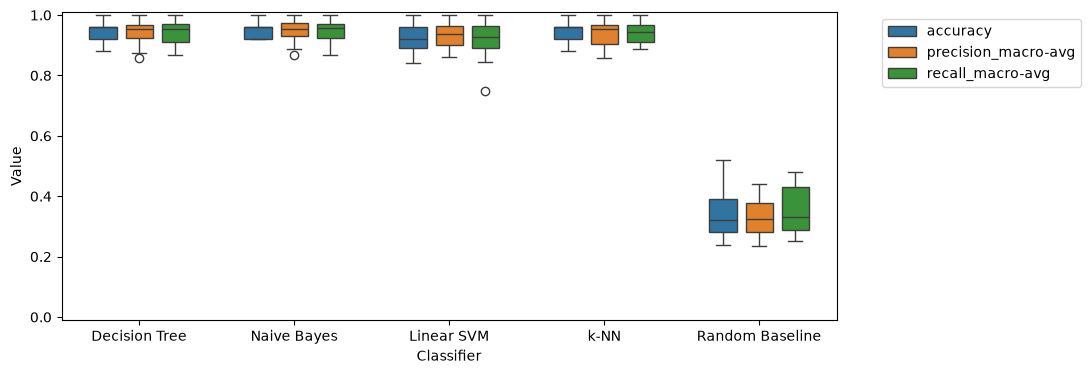

In [50]:
plot_metrics = ["accuracy", "precision_macro-avg", "recall_macro-avg"]
apr_palette = seaborn.color_palette("tab10", n_colors=len(plot_metrics))
_, ax = plt.subplots(figsize=(10, 4))
seaborn.boxplot(data=results_dtf[results_dtf["Score"].isin(plot_metrics)],
                width=0.7, dodge=True, gap=0.25, x="Classifier", y="Value", hue="Score",
                hue_order=plot_metrics, ax=ax, palette=apr_palette)
ax.set_ylim(-0.01,1.01)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left");

To inspect the performance of the classifiers in terms of precision and recall in more details, we display the macro-average score along with the per-class score for each classifier.

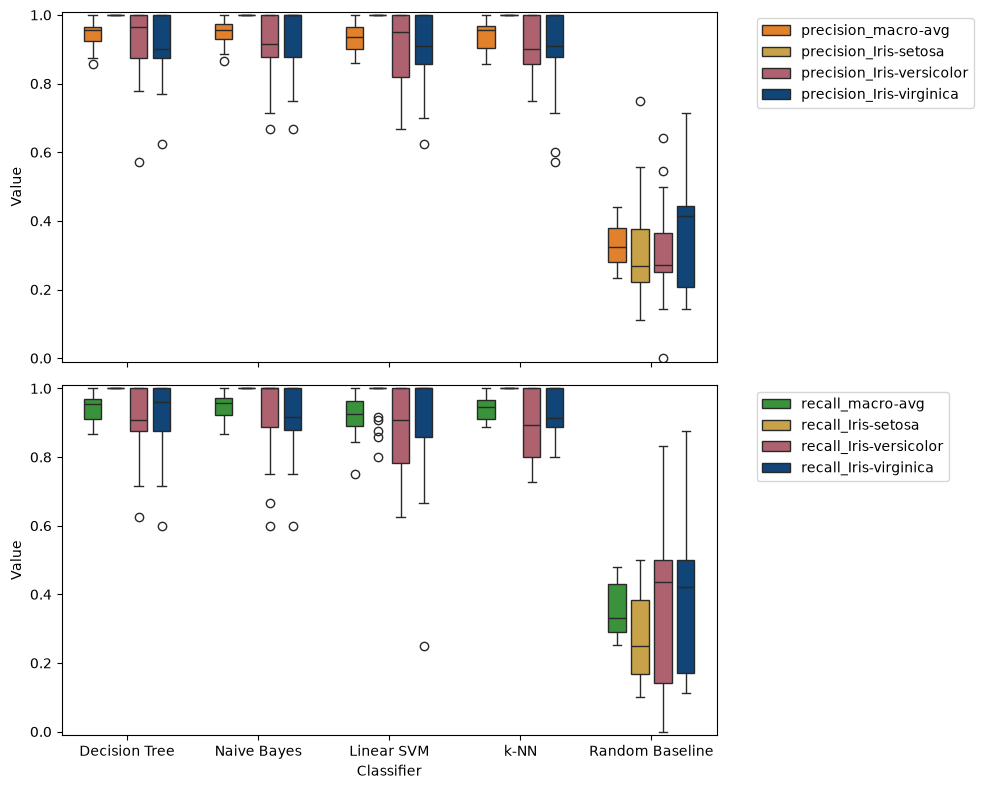

In [51]:
f, axes = plt.subplots(len(plot_metrics[1:]), 1)
for i, met in enumerate(plot_metrics[1:]):
    base_met = met.split("_")[0]
    splot_metrics = [met] + [f"{base_met}_{cname}" for ci, cname in enumerate(unique_classes)]
    smet_palette = seaborn.color_palette([apr_palette[i+1]]+[species_to_colors[s] for s in unique_classes])

    seaborn.boxplot(data=results_dtf[results_dtf["Score"].isin(splot_metrics)],
                width=0.7, dodge=True, gap=0.25, x="Classifier", y="Value", hue="Score",
                ax=axes[i], hue_order=splot_metrics, palette=smet_palette)
    axes[i].set_ylim(-0.01,1.01)
    if i+1 < len(plot_metrics[1:]):
        axes[i].set_xticks(axes[i].get_xticks(), [])
        axes[i].set_xlabel(None)
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc="upper left");

f.set_figheight(8)
f.tight_layout()

✏️ <span style="background-color:#FEDA8B;">
Write a few sentences to describe your observations about the distribution of scores for the different classifiers shown in the three plots above, and to explain what it means in terms of the comparative performance of the classifiers.
What are the different types of prediction errors produced by the classifiers? Which classifiers are performing best?
</span>

We use the *pivot* operation to reshape the data so that the values of the different performance scores are listed as different columns with one row for each model.

In [52]:
pivoted_dtf = results_dtf.pivot(index=["Classifier", "Round"], columns="Score", values="Value")

We can then for example compare the detailed results for the first round of the decision tree, the k-nearest neighbor and the random baseline.

In [53]:
pivoted_dtf.loc[[("Decision Tree", 1), ("k-NN", 1), ("Random Baseline", 1)]]

,Score,accuracy,cm-0-0,cm-0-1,cm-0-2,cm-1-0,cm-1-1,cm-1-2,cm-2-0,cm-2-1,cm-2-2,precision_Iris-setosa,precision_Iris-versicolor,precision_Iris-virginica,precision_macro-avg,recall_Iris-setosa,recall_Iris-versicolor,recall_Iris-virginica,recall_macro-avg
Classifier,Round,,,,,,,,,,,,,,,,,,
Decision Tree,1,0.88,10.0,0.0,0.0,0.0,4.0,0.0,0.0,3.0,8.0,1.000,0.571429,1.000000,0.857143,1.0,1.000,0.727273,0.909091
k-NN,1,0.96,10.0,0.0,0.0,0.0,9.0,0.0,0.0,1.0,5.0,1.000,0.900000,1.000000,0.966667,1.0,1.000,0.833333,0.944444
Random Baseline,1,0.52,3.0,3.0,0.0,3.0,1.0,4.0,2.0,0.0,9.0,0.375,0.250000,0.692308,0.439103,0.5,0.125,0.818182,0.481061


We show descriptive statistics of the performance scores over all classifiers.

In [54]:
pivoted_dtf.describe()

Score,accuracy,cm-0-0,cm-0-1,cm-0-2,cm-1-0,cm-1-1,cm-1-2,cm-2-0,cm-2-1,cm-2-2,precision_Iris-setosa,precision_Iris-versicolor,precision_Iris-virginica,precision_macro-avg,recall_Iris-setosa,recall_Iris-versicolor,recall_Iris-virginica,recall_macro-avg
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,0.825067,7.093333,0.780000,0.460000,0.526667,6.713333,1.093333,0.493333,1.020000,6.820000,0.861865,0.795129,0.807503,0.821499,0.851004,0.801803,0.816522,0.823109
std,0.242029,3.141723,1.637931,1.059505,1.218959,2.997396,1.200373,1.109729,1.250342,2.891947,0.284118,0.265190,0.244279,0.249468,0.293868,0.253326,0.253905,0.240921
min,0.240000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.111111,0.000000,0.142857,0.233766,0.100000,0.000000,0.111111,0.251082
25%,0.880000,5.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.777778,0.750000,0.870536,1.000000,0.732955,0.800000,0.866931
50%,0.920000,8.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,1.000000,7.000000,1.000000,0.888889,0.888889,0.933333,1.000000,0.888889,0.900000,0.925926
75%,0.960000,9.000000,0.000000,0.000000,0.000000,9.000000,2.000000,0.000000,2.000000,9.000000,1.000000,1.000000,1.000000,0.962963,1.000000,1.000000,1.000000,0.965741
max,1.000000,14.000000,9.000000,5.000000,6.000000,15.000000,6.000000,4.000000,6.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


And the same statistics, but considering only experiments with a decision tree classifier.

In [55]:
pivoted_dtf.loc["Decision Tree"].describe()

Score,accuracy,cm-0-0,cm-0-1,cm-0-2,cm-1-0,cm-1-1,cm-1-2,cm-2-0,cm-2-1,cm-2-2,precision_Iris-setosa,precision_Iris-versicolor,precision_Iris-virginica,precision_macro-avg,recall_Iris-setosa,recall_Iris-versicolor,recall_Iris-virginica,recall_macro-avg
count,30.000000,30.000000,30.0,30.0,30.0,30.000000,30.000000,30.0,30.00000,30.000000,30.0,30.000000,30.000000,30.000000,30.0,30.000000,30.000000,30.000000
mean,0.942667,8.333333,0.0,0.0,0.0,7.600000,0.733333,0.0,0.70000,7.633333,1.0,0.920617,0.914900,0.945172,1.0,0.914713,0.916927,0.943880
std,0.038857,2.005739,0.0,0.0,0.0,2.252967,0.827682,0.0,0.83666,2.025413,0.0,0.101046,0.091495,0.038347,0.0,0.097820,0.104987,0.040121
min,0.880000,3.000000,0.0,0.0,0.0,4.000000,0.000000,0.0,0.00000,3.000000,1.0,0.571429,0.625000,0.857143,1.0,0.625000,0.600000,0.866667
25%,0.920000,7.000000,0.0,0.0,0.0,6.000000,0.000000,0.0,0.00000,7.000000,1.0,0.875000,0.875000,0.923558,1.0,0.875000,0.875000,0.911869
50%,0.960000,9.000000,0.0,0.0,0.0,7.000000,1.000000,0.0,0.50000,8.000000,1.0,0.964286,0.900000,0.955357,1.0,0.909091,0.961538,0.955357
75%,0.960000,10.000000,0.0,0.0,0.0,9.750000,1.000000,0.0,1.00000,8.750000,1.0,1.000000,1.000000,0.965741,1.0,1.000000,1.000000,0.969697
max,1.000000,12.000000,0.0,0.0,0.0,13.000000,3.000000,0.0,3.00000,13.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000


✏️ <span style="background-color:#FEDA8B;">
You may add a few sentences to further discuss the numerical results of the classifier comparison.
</span>

## Conclusion

✏️ <span style="background-color:#FEDA8B;">
Write a few sentences of conclusion, summarizing what you have learned from the notebook, about the dataset, the classifiers, the evaluation process and the analysis pipeline.
</span>